In [ ]:
#  Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("All imports successful")

Matplotlib is building the font cache; this may take a moment.


All imports successful


In [ ]:
# Load and preprocess data
df = pd.read_csv('../data/HR-Employee-Attrition.csv')

# Drop useless columns
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

# Encode target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
print("Encoding columns:", list(categorical_cols))

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nShape after preprocessing:", df.shape)
print("Any nulls:", df.isnull().sum().sum())
df.head()

Encoding columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after preprocessing: (1470, 31)
Any nulls: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
# Split features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print(f"\nClass imbalance: {y.mean()*100:.1f}% positive (attrition)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]} rows")
print(f"Test size : {X_test.shape[0]} rows")
print(f"Train attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test  attrition rate: {y_test.mean()*100:.1f}%")

Features shape: (1470, 30)
Target distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64

Class imbalance: 16.1% positive (attrition)

Train size: 1176 rows
Test size : 294 rows
Train attrition rate: 16.2%
Test  attrition rate: 16.0%


In [ ]:
# Fix class imbalance with SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print(f"\nTraining set now perfectly balanced: {len(X_train_bal)} total rows")

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64

Training set now perfectly balanced: 1972 total rows


In [ ]:
# Baseline model (before tuning)
baseline = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
baseline.fit(X_train_bal, y_train_bal)

baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f"Baseline XGBoost AUC (no tuning): {baseline_auc:.3f}")

Baseline XGBoost AUC (no tuning): 0.741


In [ ]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print("\nBest parameters:", grid_search.best_params_)
print(f"Best CV AUC    : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC    : 0.963


In [ ]:
# Evaluate best model on test set
best_model = grid_search.best_estimator_

y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

tuned_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"Baseline AUC : {baseline_auc:.3f}")
print(f"Tuned AUC    : {tuned_auc:.3f}")
print(f"Improvement  : +{(tuned_auc - baseline_auc):.3f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))

MODEL PERFORMANCE ON TEST SET
Baseline AUC : 0.741
Tuned AUC    : 0.763
Improvement  : +0.022

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.91      0.90       247
        Left       0.43      0.34      0.38        47

    accuracy                           0.82       294
   macro avg       0.66      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294



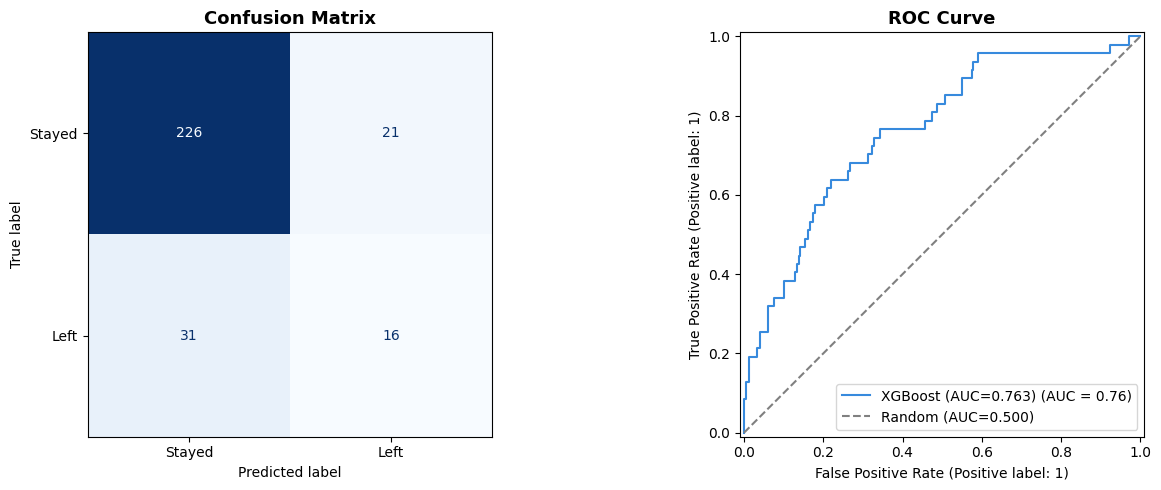

Saved: model_evaluation.png


In [ ]:
# Confusion matrix chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                  name=f'XGBoost (AUC={tuned_auc:.3f})',
                                  color='#378ADD')
axes[1].plot([0,1],[0,1],'--',color='gray',label='Random (AUC=0.500)')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_evaluation.png")

In [ ]:
# Save model and feature names
joblib.dump(best_model, '../model.pkl')
joblib.dump(list(X.columns), '../feature_names.pkl')

print("model.pkl saved")
print("feature_names.pkl saved")
print(f"\nFeatures used ({len(X.columns)}):")
print(list(X.columns))

model.pkl saved
feature_names.pkl saved

Features used (30):
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
